<a href="https://colab.research.google.com/github/tanuiivy/bbt4106-202604-D4-regression/blob/feature%2Fexplainability-maxwell/bbt4106_202604_D4_d_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Annual Farm Income: A Regression Analysis of Kenyan Smallholder and Commercial Farms
### BBT4106 — Business Intelligence I | Group D4

## 1. Setup & Dependencies

In [2]:
# Install `ipykernel` for Jupyter notebook
%pip install ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.9 MB/s eta 0:00:00


In [3]:
# Setup & Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
import urllib.request
import os


# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')

TARGET = 'annual_farm_income_kes'

## 2. Data Loading & Exploratory Data Analysis

In [4]:
# Load the Dataset
dataset_path = './data/farm_annual_income.csv'
url = 'https://raw.githubusercontent.com/tanuiivy/bbt4106-202604-D4-regression/refs/heads/main/farm_annual_income.csv'

if not os.path.exists(dataset_path):
    print("Downloading dataset...")
    if not os.path.exists('./data'):
        os.makedirs('./data')
    urllib.request.urlretrieve(url, dataset_path)
    print("Dataset downloaded✅ ")
else:
    print("Dataset already exists locally✅ ")

# EXCLUDING "None" (which is a real category in irrigation_type, not a gap):
default_na_minus_none = ['', '#N/A', '#N/A N/A', '#NA', '-1.#IND', '-1.#QNAN', '-NaN', '-nan',
                          '1.#IND', '1.#QNAN', '<NA>', 'N/A', 'NA', 'NULL', 'NaN',
                          'n/a', 'nan', 'null']

farm_data = pd.read_csv(dataset_path, encoding='utf-8',
                         keep_default_na=False, na_values=default_na_minus_none)
print(f"Shape: {farm_data.shape[0]} rows, {farm_data.shape[1]} columns")
farm_data.head()

Dataset downloaded✅ 
Shape: 850 rows, 16 columns


,farm_id,crop_type,county,irrigation_type,cooperative_member,farm_size_acres,years_farming_experience,num_workers_employed,rainfall_mm,soil_quality_score,market_distance_km,machinery_value_kes,fertilizer_spend_kes,pesticide_spend_kes,irrigation_maintenance_cost_kes,annual_farm_income_kes
0,1,Tea,Uasin Gishu,Drip,No,7.26,10.0,1,1345.0,NaN,5.7,31304.0,22569.0,11598.0,20609.323557,240514.0
1,2,Tea,Nakuru,Drip,No,15.73,39.8,4,739.0,38.000299,11.3,156636.0,52716.0,13887.0,2849.905605,562457.0
2,3,Tea,Uasin Gishu,None,No,7.75,3.3,2,1101.0,57.136048,29.3,15966.0,28291.0,10697.0,NaN,176021.0
3,4,Coffee,Nakuru,None,No,3.90,30.6,1,831.0,73.593459,14.1,29920.0,16108.0,5383.0,NaN,283876.0
4,5,Tea,Kericho,Manual,No,10.49,9.3,1,967.0,54.498549,6.0,115136.0,28664.0,4486.0,3207.355224,242651.0


### 2.1 Shape, Data Types & Target Overview

In [5]:
# 2.1 Shape, Data Types & Target
farm_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   farm_id                          850 non-null    int64  
 1   crop_type                        850 non-null    object 
 2   county                           850 non-null    object 
 3   irrigation_type                  850 non-null    object 
 4   cooperative_member               850 non-null    object 
 5   farm_size_acres                  850 non-null    float64
 6   years_farming_experience         850 non-null    float64
 7   num_workers_employed             850 non-null    int64  
 8   rainfall_mm                      850 non-null    float64
 9   soil_quality_score               807 non-null    float64
 10  market_distance_km               850 non-null    float64
 11  machinery_value_kes              850 non-null    float64
 12  fertilizer_spend_kes  

In [6]:
print(f"Target variable: {TARGET}")

Target variable: annual_farm_income_kes


In [7]:
farm_data[TARGET].describe()

,annual_farm_income_kes
count,8.500000e+02
mean,2.686471e+05
std,1.608326e+05
min,5.653400e+04
25%,1.683308e+05
50%,2.237460e+05
75%,3.279118e+05
max,2.060104e+06


In [8]:
print(f"Number of features (excluding IDs and the target): {farm_data.shape[1] - 2}")

Number of features (excluding IDs and the target): 14


### 2.2 Measures of Central Tendency & Distribution

In [9]:
""" Split columns into numeric (measures) and categorical (dimensions) so we can apply the right statistics to each:
central tendency/distribution measures for numeric columns, frequency tables for categorical ones."""

numeric_cols = farm_data.select_dtypes(include=[np.number]).columns.drop('farm_id')
categorical_cols = farm_data.select_dtypes(exclude=[np.number]).columns

print("Numeric columns (measures):")
print(numeric_cols.tolist())

print("\nCategorical columns (dimensions):")
print(categorical_cols.tolist())

Numeric columns (measures):
['farm_size_acres', 'years_farming_experience', 'num_workers_employed', 'rainfall_mm', 'soil_quality_score', 'market_distance_km', 'machinery_value_kes', 'fertilizer_spend_kes', 'pesticide_spend_kes', 'irrigation_maintenance_cost_kes', 'annual_farm_income_kes']

Categorical columns (dimensions):
['crop_type', 'county', 'irrigation_type', 'cooperative_member']


In [10]:
# Summarise the frequency and percentage of each categorical variable

for col in categorical_cols:
    print(f"\n--- {col} ---")
    freq_table = farm_data[col].value_counts(dropna=False)
    pct_table = farm_data[col].value_counts(normalize=True, dropna=False) * 100
    summary = pd.DataFrame({'count': freq_table, 'percent': pct_table.round(1)})
    print(summary)


--- crop_type ---
              count  percent
crop_type                   
Maize           266     31.3
Tea             171     20.1
Horticulture    171     20.1
Dairy           138     16.2
Coffee          104     12.2

--- county ---
             count  percent
county                     
Other          180     21.2
Nakuru         168     19.8
Kiambu         137     16.1
Kericho        128     15.1
Meru           121     14.2
Uasin Gishu    116     13.6

--- irrigation_type ---
                 count  percent
irrigation_type                
None               303     35.6
Manual             225     26.5
Drip               198     23.3
Automated          124     14.6

--- cooperative_member ---
                    count  percent
cooperative_member                
Yes                   483     56.8
No                    367     43.2


In [11]:
# Calculate descriptive statistics and distribution measures for numeric variables

q1 = farm_data[numeric_cols].quantile(0.25)
q2 = farm_data[numeric_cols].quantile(0.50)
q3 = farm_data[numeric_cols].quantile(0.75)
iqr = q3 - q1

distribution_summary = pd.DataFrame({
    "min": farm_data[numeric_cols].min(),
    "q1_25%": q1,
    "q2_50%_median": q2,
    "q3_75%": q3,
    "max": farm_data[numeric_cols].max(),
    "mean": farm_data[numeric_cols].mean(),
    "mode": farm_data[numeric_cols].mode().iloc[0],
    "variance": farm_data[numeric_cols].var(),
    "std_dev": farm_data[numeric_cols].std(),
    "skewness": farm_data[numeric_cols].skew(),
    "kurtosis": farm_data[numeric_cols].kurt(),
    "IQR": iqr,
    "lower_fence": q1 - 1.5 * iqr,
    "upper_fence": q3 + 1.5 * iqr,
})

distribution_summary.round(2)

,min,q1_25%,q2_50%_median,q3_75%,max,mean,mode,variance,std_dev,skewness,kurtosis,IQR,lower_fence,upper_fence
farm_size_acres,0.5,3.90,6.34,10.09,31.44,7.68,3.04,2.651000e+01,5.15,1.19,1.40,6.19,-5.38,19.38
years_farming_experience,0.5,6.72,11.40,17.70,45.00,13.37,6.20,7.850000e+01,8.86,1.25,1.56,10.98,-9.74,34.16
num_workers_employed,0.0,1.00,2.00,3.00,9.00,2.03,1.00,2.830000e+00,1.68,0.76,0.26,2.00,-2.00,6.00
rainfall_mm,250.0,800.00,951.00,1091.75,1566.00,946.02,951.00,4.775720e+04,218.53,0.02,-0.08,291.75,362.38,1529.38
soil_quality_score,5.0,49.73,61.61,73.89,100.00,61.63,100.00,2.950900e+02,17.18,-0.16,-0.12,24.16,13.50,110.13
market_distance_km,1.0,8.10,13.65,22.20,68.50,16.39,1.00,1.322700e+02,11.50,1.27,1.81,14.10,-13.05,43.35
machinery_value_kes,0.0,29763.50,56409.50,95019.00,350170.00,69103.23,0.00,3.042008e+09,55154.40,1.31,1.92,65255.50,-68119.75,192902.25
fertilizer_spend_kes,1104.0,11143.00,19577.00,33529.00,133274.00,24391.90,10424.00,3.312240e+08,18199.56,1.58,3.73,22386.00,-22436.00,67108.00
pesticide_spend_kes,199.0,4718.25,8587.50,13805.25,50169.00,10560.84,1540.00,6.843423e+07,8272.50,1.63,3.43,9087.00,-8912.25,27435.75
irrigation_maintenance_cost_kes,500.0,4057.64,7532.92,12234.66,36866.42,8994.86,500.00,4.036150e+07,6353.07,1.30,2.00,8177.02,-8207.89,24500.19


In [12]:
print(f"""
The target variable, annual_farm_income_kes, shows the most extreme distribution shape in the dataset:
skewness of {distribution_summary.loc['annual_farm_income_kes', 'skewness']:.2f} and kurtosis of {distribution_summary.loc['annual_farm_income_kes', 'kurtosis']:.2f}.
A skewness this high (well above the common >1 threshold for 'highly skewed') confirms a strong right skew:
most farms earn moderate income, but a small number of very high-income farms pull the mean (KES 268,647) well above the median (KES 223,746).
The kurtosis of 23.58 is exceptionally high compared to every other numeric column in the dataset.
This signals heavy tails, meaning extreme outlier farms exist far beyond what a normal distribution would predict.
This will require a variance-stabilizing transform (log1p, Box-Cox, or Yeo-Johnson) during preprocessing,
and diagnostic checks like Cook's distance will likely flag these same high-income farms as influential points.
""")


The target variable, annual_farm_income_kes, shows the most extreme distribution shape in the dataset:
skewness of 3.38 and kurtosis of 23.58.
A skewness this high (well above the common >1 threshold for 'highly skewed') confirms a strong right skew:
most farms earn moderate income, but a small number of very high-income farms pull the mean (KES 268,647) well above the median (KES 223,746).
The kurtosis of 23.58 is exceptionally high compared to every other numeric column in the dataset.
This signals heavy tails, meaning extreme outlier farms exist far beyond what a normal distribution would predict.
This will require a variance-stabilizing transform (log1p, Box-Cox, or Yeo-Johnson) during preprocessing,
and diagnostic checks like Cook's distance will likely flag these same high-income farms as influential points.



In [13]:
print("""
These distribution shapes carry directly into later stages:
the target's extreme skew and kurtosis mean a transformation is very likely necessary before modeling (Section 5.3),
and the same high-income farms that inflate skew here are the ones most likely to surface as high-leverage points in diagnostics (Section 7) and outliers worth investigating rather than automatically deleting.
""")


These distribution shapes carry directly into later stages:
the target's extreme skew and kurtosis mean a transformation is very likely necessary before modeling (Section 5.3),
and the same high-income farms that inflate skew here are the ones most likely to surface as high-leverage points in diagnostics (Section 7) and outliers worth investigating rather than automatically deleting.



### 2.3 Skewness, Kurtosis & Outlier Detection (IQR/Boxplot)

In [ ]:
""" Identify values below the lower fence or above the upper fence for each numeric column.
Per 2.2, lower fences are meaningless for the KES columns (negative), so in practice this mainly catches upper-tail outliers."""

outlier_mask = (
    (farm_data[numeric_cols] < (q1 - 1.5 * iqr)) |
    (farm_data[numeric_cols] > (q3 + 1.5 * iqr))
)

outlier_counts = outlier_mask.sum().rename("outlier_count").to_frame()
outlier_counts

,outlier_count
farm_size_acres,35
years_farming_experience,31
num_workers_employed,10
rainfall_mm,5
soil_quality_score,5
market_distance_km,30
machinery_value_kes,34
fertilizer_spend_kes,28
pesticide_spend_kes,37
irrigation_maintenance_cost_kes,16


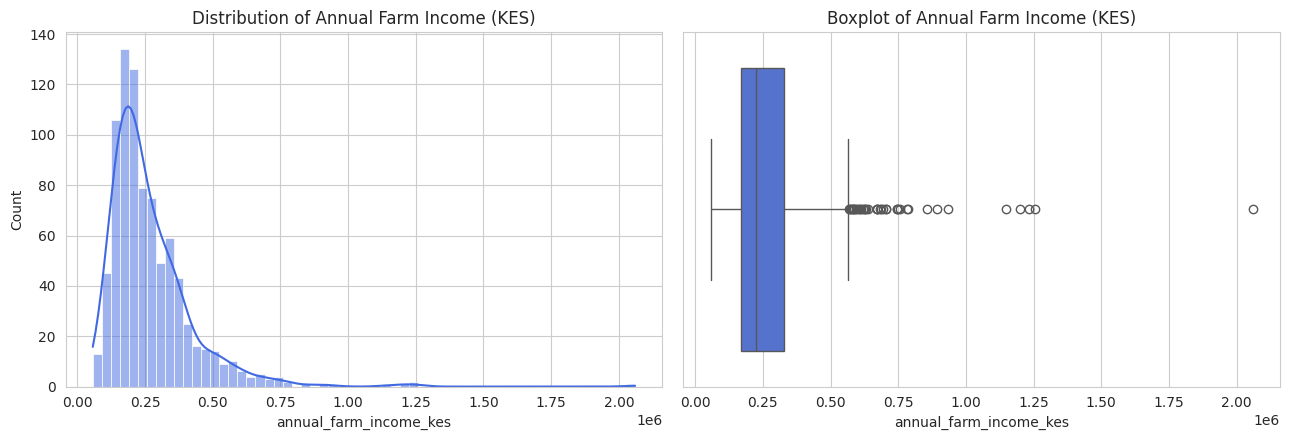

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histogram: "Count" shows the number of farms in each income range.
# The x-axis uses scientific notation because income values are large.
# For example, "1e6" means 1,000,000 (KES 1 million).

sns.histplot(farm_data[TARGET], kde=True, ax=axes[0], color="#4169E1")
axes[0].set_title("Distribution of Annual Farm Income (KES)")

# Boxplot: box = middle 50% of farms, line = median, dots = outliersbeyond the 1.5×IQR fences from 2.2/2.3.
sns.boxplot(x=farm_data[TARGET], ax=axes[1], color="#4169E1")
axes[1].set_title("Boxplot of Annual Farm Income (KES)")

plt.tight_layout()
plt.show()

In [16]:
outlier_mask = (
    (farm_data[numeric_cols] < (q1 - 1.5 * iqr)) |
    (farm_data[numeric_cols] > (q3 + 1.5 * iqr))
)

outlier_counts = outlier_mask.sum().rename("outlier_count").to_frame()
n_income_outliers = outlier_counts.loc[TARGET, 'outlier_count']
print(f"""
The histogram confirms the right skew already seen numerically:
a dense cluster of farms in the KES 150,000-350,000 range, with a long thin tail stretching toward KES 2,000,000.
The boxplot shows {n_income_outliers} farms flagged as statistical outliers using the 1.5×IQR rule.
These are the same high-income commercial farms driving the skewness of 3.38 and kurtosis of 23.58 computed in 2.2.
Rather than deleting these rows outright, they warrant individual inspection later, since they may represent genuine large commercial operations rather than data-entry errors.
""")


The histogram confirms the right skew already seen numerically:
a dense cluster of farms in the KES 150,000-350,000 range, with a long thin tail stretching toward KES 2,000,000.
The boxplot shows 39 farms flagged as statistical outliers using the 1.5×IQR rule.
These are the same high-income commercial farms driving the skewness of 3.38 and kurtosis of 23.58 computed in 2.2.
Rather than deleting these rows outright, they warrant individual inspection later, since they may represent genuine large commercial operations rather than data-entry errors.



### 2.4 Correlation & Relationship Analysis

In [17]:
# Pearson correlation captures linear relationships; Spearman captures monotonic, possibly non-linear relationships.
# Comparing the two flags predictors where the relationship isn't a straight line.

pearson_corr = farm_data[numeric_cols].corr(method="pearson")[TARGET].drop(TARGET).sort_values(ascending=False)
spearman_corr = farm_data[numeric_cols].corr(method="spearman")[TARGET].drop(TARGET).sort_values(ascending=False)

relationship_summary = pd.DataFrame({"Pearson": pearson_corr, "Spearman": spearman_corr})
relationship_summary["gap"] = (relationship_summary["Spearman"] - relationship_summary["Pearson"]).abs()
relationship_summary.sort_values("gap", ascending=False).round(3)

,Pearson,Spearman,gap
rainfall_mm,0.057,0.118,0.062
soil_quality_score,0.128,0.160,0.031
irrigation_maintenance_cost_kes,0.026,0.055,0.029
years_farming_experience,0.528,0.512,0.016
machinery_value_kes,0.003,-0.010,0.013
farm_size_acres,0.010,-0.002,0.012
pesticide_spend_kes,-0.010,-0.002,0.009
fertilizer_spend_kes,0.008,0.001,0.007
market_distance_km,-0.071,-0.070,0.001
num_workers_employed,0.048,0.047,0.001


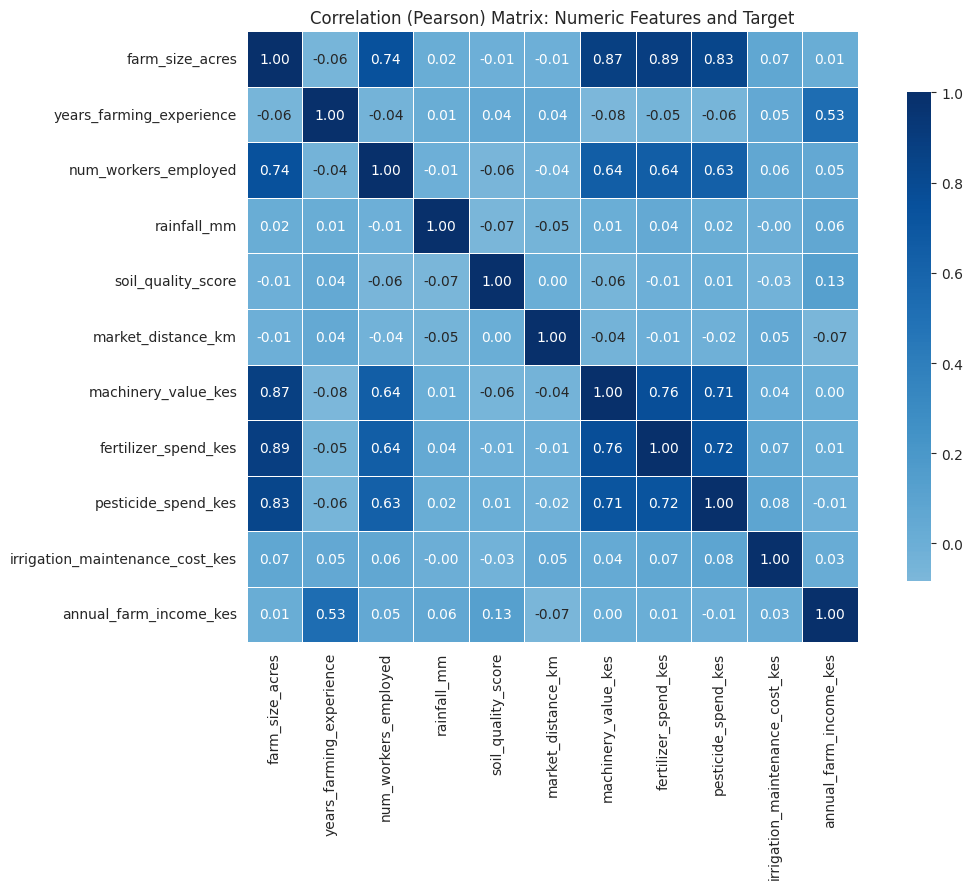

In [18]:
plt.figure(figsize=(12, 9))

corr_matrix = farm_data[numeric_cols].corr(method="pearson")
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Correlation (Pearson) Matrix: Numeric Features and Target")
plt.tight_layout()
plt.show()

In [19]:
print(f"""
years_farming_experience shows by far the strongest relationship with annual_farm_income_kes
(Pearson {relationship_summary.loc['years_farming_experience','Pearson']:.2f}, Spearman {relationship_summary.loc['years_farming_experience','Spearman']:.2f}) — a moderate positive correlation. Every other numeric feature, including farm_size_acres (0.01),
machinery_value_kes (0.00), fertilizer_spend_kes (0.01), and pesticide_spend_kes (-0.01),
shows essentially no linear or monotonic relationship with income at all.
This is a genuinely counter-intuitive finding: farm scale and input spending do not, on their own, predict how much a farm earns, experience does.
This suggests income may depend more on farming skill/practice than on physical scale, or that the relationship between spending and income is more complex than a simple linear or monotonic one
(e.g. it may only pay off in combination with experience).
""")


years_farming_experience shows by far the strongest relationship with annual_farm_income_kes
(Pearson 0.53, Spearman 0.51) — a moderate positive correlation. Every other numeric feature, including farm_size_acres (0.01),
machinery_value_kes (0.00), fertilizer_spend_kes (0.01), and pesticide_spend_kes (-0.01),
shows essentially no linear or monotonic relationship with income at all.
This is a genuinely counter-intuitive finding: farm scale and input spending do not, on their own, predict how much a farm earns, experience does.
This suggests income may depend more on farming skill/practice than on physical scale, or that the relationship between spending and income is more complex than a simple linear or monotonic one
(e.g. it may only pay off in combination with experience).



In [20]:
print("""
The heatmap reveals a clear multicollinearity cluster: farm_size_acres correlates strongly with machinery_value_kes (0.87), fertilizer_spend_kes (0.89), pesticide_spend_kes (0.83), and num_workers_employed (0.74).
These four inputs also correlate moderately with each other (0.63-0.76).
This makes practical sense as larger farms naturally need more machinery, more workers, and more fertilizer/pesticide simply due to scale, not because each input independently drives outcomes.
This cluster is flagged here for Section 2 (Feature Selection): VIF analysis will very likely need to drop or combine several of these five correlated columns to avoid redundant, unstable coefficients in the regression model.
""")


The heatmap reveals a clear multicollinearity cluster: farm_size_acres correlates strongly with machinery_value_kes (0.87), fertilizer_spend_kes (0.89), pesticide_spend_kes (0.83), and num_workers_employed (0.74).
These four inputs also correlate moderately with each other (0.63-0.76).
This makes practical sense as larger farms naturally need more machinery, more workers, and more fertilizer/pesticide simply due to scale, not because each input independently drives outcomes.
This cluster is flagged here for Section 2 (Feature Selection): VIF analysis will very likely need to drop or combine several of these five correlated columns to avoid redundant, unstable coefficients in the regression model.



In [21]:
print("""
As with any correlation analysis, these relationships describe association, not causation.
A positive correlation between years_farming_experience and income does not prove that experience alone causes higher earnings;
unmeasured factors (e.g. crop choice, county-level market access) could influence both.""")


As with any correlation analysis, these relationships describe association, not causation.
A positive correlation between years_farming_experience and income does not prove that experience alone causes higher earnings;
unmeasured factors (e.g. crop choice, county-level market access) could influence both.


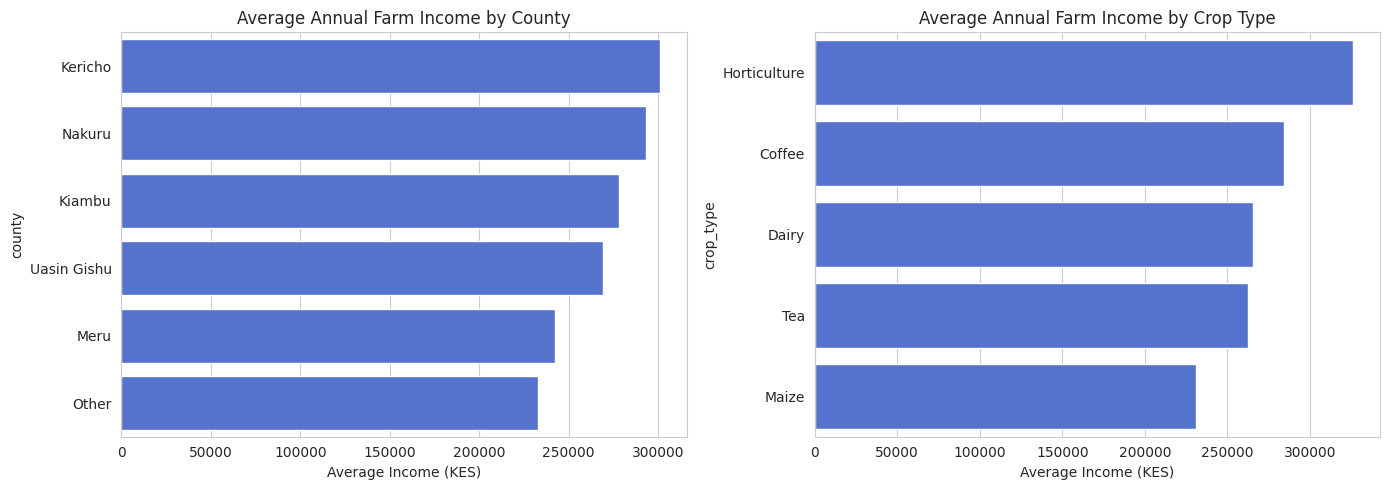

In [22]:
# Combine a dimension (categorical) with the target (measure).
# Showing a side by side for county and crop_type since both are business-relevant groupings for farm income specifically.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

county_avg = farm_data.groupby('county')[TARGET].mean().sort_values(ascending=False)
sns.barplot(x=county_avg.values, y=county_avg.index, ax=axes[0], color="#4169E1")
axes[0].set_title("Average Annual Farm Income by County")
axes[0].set_xlabel("Average Income (KES)")

crop_avg = farm_data.groupby('crop_type')[TARGET].mean().sort_values(ascending=False)
sns.barplot(x=crop_avg.values, y=crop_avg.index, ax=axes[1], color="#4169E1")
axes[1].set_title("Average Annual Farm Income by Crop Type")
axes[1].set_xlabel("Average Income (KES)")

plt.tight_layout()
plt.show()

In [23]:
print(f"""
County averages range from roughly KES {county_avg.min():,.0f} ({county_avg.idxmin()}) to KES {county_avg.max():,.0f} ({county_avg.idxmax()}),
while crop-type averages range from KES {crop_avg.min():,.0f} ({crop_avg.idxmin()}) to KES {crop_avg.max():,.0f} ({crop_avg.idxmax()}).
Horticulture farms earn the most on average, roughly 40% more than Maize farms, and Kericho county farms outearn the "Other" county grouping by a similar margin.
These gaps are real but still smaller than the spread driven by years_farming_experience (Pearson 0.53), suggesting crop choice and location matter,
but farmer experience remains the dominant single factor in this dataset.
""")


County averages range from roughly KES 232,736 (Other) to KES 301,020 (Kericho),
while crop-type averages range from KES 230,882 (Maize) to KES 326,191 (Horticulture).
Horticulture farms earn the most on average, roughly 40% more than Maize farms, and Kericho county farms outearn the "Other" county grouping by a similar margin.
These gaps are real but still smaller than the spread driven by years_farming_experience (Pearson 0.53), suggesting crop choice and location matter,
but farmer experience remains the dominant single factor in this dataset.



## 3. Train/Test Split

####The Split ####

In [24]:
# Create a temporary binned target purely for stratification purposes.
# Given annual_farm_income_kes's strong right skew (skewness 3.38), a plain random split risks placing a disproportionate share of high-income farms into either train or test.
# Quantile binning ensures both sets contain a comparable mix of low-, medium-, and high-income farms.

income_bins = pd.qcut(farm_data[TARGET], q=5, labels=False, duplicates="drop")

X = farm_data.drop(columns=['farm_id', TARGET])
y = farm_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=income_bins
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 680 rows
Test set: 170 rows


In [25]:
print(f"""
An 80/20 split was chosen given the dataset's moderate size (850 rows),
allocating {X_train.shape[0]} farms for training and {X_test.shape[0]} for testing.
Because the target is heavily right-skewed, the split was stratified on quantile-based income bins
(5 bins via pd.qcut) rather than performed as a plain random split ensuring both sets contain a comparable mix of low-, medium-, and high-income farms.
""")


An 80/20 split was chosen given the dataset's moderate size (850 rows),
allocating 680 farms for training and 170 for testing.
Because the target is heavily right-skewed, the split was stratified on quantile-based income bins
(5 bins via pd.qcut) rather than performed as a plain random split ensuring both sets contain a comparable mix of low-, medium-, and high-income farms.



**Hypothesis Formulation**

Based on the patterns observed in the EDA above, we formulate the following hypothesis for the modeling stage:

H1: years_farming_experience is the strongest predictor of annual_farm_income_kes among the numeric features examined, given its moderate positive correlation (Pearson 0.53) compared to near-zero "correlations for farm_size_acres, machinery_value_kes, and the input spending variables. This suggests income is driven more by farming practice/skill accumulated over time than by physical scale or capital investment alone.

H2: The farm_size_acres cluster (farm_size_acres, machinery_value_kes,fertilizer_spend_kes, pesticide_spend_kes, num_workers_employed) exhibits multicollinearity and will require dimensionality reduction or feature
selection before modeling to avoid unstable coefficient estimates.

## 4. Feature Selection

### 4.1 Correlation Filtering

In [26]:
numeric_train = X_train.select_dtypes(include=[np.number])
train_corr = numeric_train.corr(method='pearson').abs()

high_corr_pairs = [
    (train_corr.columns[i], train_corr.columns[j], train_corr.iloc[i, j])
    for i in range(len(train_corr.columns))
    for j in range(i + 1, len(train_corr.columns))
    if train_corr.iloc[i, j] > 0.8
]
for pair in sorted(high_corr_pairs, key=lambda x: -x[2]):
    print(pair)

('farm_size_acres', 'fertilizer_spend_kes', np.float64(0.8843738133514565))
('farm_size_acres', 'machinery_value_kes', np.float64(0.8757763034096318))
('farm_size_acres', 'pesticide_spend_kes', np.float64(0.834804166568751))


In [27]:
target_corr = X_train.select_dtypes(include=[np.number]).assign(**{TARGET: y_train}).corr()[TARGET].drop(TARGET)
print(target_corr.sort_values(ascending=False))

years_farming_experience           0.511159
soil_quality_score                 0.142545
rainfall_mm                        0.039563
num_workers_employed               0.037988
irrigation_maintenance_cost_kes   -0.000952
fertilizer_spend_kes              -0.006830
farm_size_acres                   -0.010044
machinery_value_kes               -0.025029
pesticide_spend_kes               -0.032437
market_distance_km                -0.054155
Name: annual_farm_income_kes, dtype: float64


In [28]:
columns_to_drop_corr = ['machinery_value_kes', 'fertilizer_spend_kes', 'pesticide_spend_kes']
X_train_corr = X_train.drop(columns=columns_to_drop_corr)
X_test_corr = X_test.drop(columns=columns_to_drop_corr)
print(f"Remaining numeric features: {X_train_corr.select_dtypes(include=[np.number]).columns.tolist()}")

Remaining numeric features: ['farm_size_acres', 'years_farming_experience', 'num_workers_employed', 'rainfall_mm', 'soil_quality_score', 'market_distance_km', 'irrigation_maintenance_cost_kes']


Above, all three dropped columns form a tight multicollinearity cluster with farm_size_acres while individually carrying near-zero linear relationship with income IE they'd inflate coefficient variance in a linear model without adding real predictive signal beyond what farm_size_acres already captures.

### 4.2 Variance Inflation Factor (VIF)

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_for_vif = X_train_corr.select_dtypes(include=[np.number]).copy()
# Temporary fill purely so VIF (which can't handle NaN) can run ie the real
# imputation strategy
numeric_for_vif['irrigation_maintenance_cost_kes'] = numeric_for_vif['irrigation_maintenance_cost_kes'].fillna(0)
numeric_for_vif['soil_quality_score'] = numeric_for_vif['soil_quality_score'].fillna(numeric_for_vif['soil_quality_score'].median())

vif_df = pd.DataFrame({
    'feature': numeric_for_vif.columns,
    'VIF': [variance_inflation_factor(numeric_for_vif.values, i) for i in range(numeric_for_vif.shape[1])]
}).sort_values('VIF', ascending=False)
vif_df

,feature,VIF
2,num_workers_employed,2.284934
0,farm_size_acres,2.274285
4,soil_quality_score,1.014438
5,market_distance_km,1.010695
1,years_farming_experience,1.010480
3,rainfall_mm,1.008593
6,irrigation_maintenance_cost_kes,1.007274


Every remaining numeric feature has VIF under 2.3 (num_workers_employed at 2.28, farm_size_acres at 2.27, all others near 1.0), well below the conservative threshold of 5.

In [30]:
vif_threshold = 5
high_vif = vif_df.loc[vif_df['VIF'] > vif_threshold, 'feature'].tolist()
print(f"Features above VIF threshold: {high_vif}")

Features above VIF threshold: []


No features exceed the VIF threshold, so no further drops are needed. Correlation filtering already removed the one genuine multicollinearity cluster in the data. VIF here confirms that the remaining 0.747-correlated pair (farm_size_acres and num_workers_employed) doesn't independently inflate coefficient variance enough to warrant removal.

### 4.3 Selected Features & Rationale

In [31]:
selected_numeric_features = ['farm_size_acres', 'years_farming_experience', 'num_workers_employed',
                              'rainfall_mm', 'soil_quality_score', 'market_distance_km',
                              'irrigation_maintenance_cost_kes']
selected_categorical_features = ['crop_type', 'county', 'irrigation_type', 'cooperative_member']

print(f"""
Two feature selection methods were applied to X_train only:
1. Correlation filtering (threshold |r|>0.8) removed machinery_value_kes, fertilizer_spend_kes,
   and pesticide_spend_kes — each near-duplicate of farm_size_acres in signal, but negligibly
   correlated with the target itself (|r|<0.03).
2. VIF (threshold 5) confirmed no further multicollinearity remains among the {len(selected_numeric_features)}
   surviving numeric features (max VIF 2.28).

All {len(selected_categorical_features)} categorical features are retained — correlation/VIF
filtering doesn't apply to unordered categories, and none showed redundancy with each other
during EDA (Section 2.3).

Final feature set: {len(selected_numeric_features)} numeric + {len(selected_categorical_features)} categorical
= {len(selected_numeric_features) + len(selected_categorical_features)} features, down from
{len(X_train.columns)} original.
""")


Two feature selection methods were applied to X_train only:
1. Correlation filtering (threshold |r|>0.8) removed machinery_value_kes, fertilizer_spend_kes,
   and pesticide_spend_kes — each near-duplicate of farm_size_acres in signal, but negligibly
   correlated with the target itself (|r|<0.03).
2. VIF (threshold 5) confirmed no further multicollinearity remains among the 7
   surviving numeric features (max VIF 2.28).

All 4 categorical features are retained — correlation/VIF
filtering doesn't apply to unordered categories, and none showed redundancy with each other
during EDA (Section 2.3).

Final feature set: 7 numeric + 4 categorical
= 11 features, down from
14 original.



## 5. Preprocessing Pipeline

### 5.1 Handling Missingness (Structural vs. Random)

In [32]:
irr_none_mask = (X_train_corr['irrigation_type'] == 'None')
maint_missing_mask = X_train_corr['irrigation_maintenance_cost_kes'].isna()
print(f"irrigation_type == 'None': {irr_none_mask.sum()} rows")
print(f"irrigation_maintenance_cost_kes missing: {maint_missing_mask.sum()} rows")
print(f"Exact match between the two: {irr_none_mask.equals(maint_missing_mask)}")

print(f"soil_quality_score missing: {X_train_corr['soil_quality_score'].isna().sum()} rows")

irrigation_type == 'None': 245 rows
irrigation_maintenance_cost_kes missing: 245 rows
Exact match between the two: True
soil_quality_score missing: 35 rows


Two distinct missingness mechanisms are present in the selected features.

Structural — irrigation_maintenance_cost_kes. Its missing rows match irrigation_type == 'None' exactly (confirmed above). A farm with no irrigation system has no maintenance cost by definition, it isn't an unknown value to estimate, it's a genuine zero. Imputing this with the median, as a random-missingness column would be, would fabricate a maintenance cost for farms that don't have an irrigation system at all. Correct treatment: fill with 0.

Random — soil_quality_score. Missing at a similarly low rate across every crop_type, county, irrigation_type, and cooperative_member group during EDA, no subgroup stands out, consistent with incidental non-response (e.g. a soil test not run that season) rather than a structural pattern. Correct treatment: statistical imputation (median, robust to its mild skew), fit on train data only.

### 5.2 Encoding & Scaling

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

general_numeric = ['farm_size_acres', 'years_farming_experience', 'num_workers_employed',
                    'rainfall_mm', 'soil_quality_score', 'market_distance_km']
structural_numeric = ['irrigation_maintenance_cost_kes']
categorical_features = ['crop_type', 'county', 'irrigation_type', 'cooperative_member']

preprocessor = ColumnTransformer(transformers=[
    ('num_random', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), general_numeric),

    ('num_structural', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value=0)),
        ('scale', StandardScaler())
    ]), structural_numeric),

    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features),
])

preprocessor.fit(X_train_corr)
print("Preprocessor fitted on training data only.")

Preprocessor fitted on training data only.


The ColumnTransformer has three branches rather than the usual two, directly reflecting Section 5.1's distinction: general_numeric gets median imputation (random missingness), structural_numeric gets a constant-zero fill (structural missingness), and categorical features get one-hot encoding. The categorical branch's SimpleImputer(strategy='most_frequent') is a defensive safety net rather than something this dataset actually exercises, irrigation_type and the other categorical columns have zero missing values post-fix, but the pipeline stays robust if a future data refresh introduces a real gap. Everything is fit on X_train_corr only, so no test-set information (e.g. category frequencies, medians) leaks into the transform.

### 5.3 Target Transformation

Raw y_train — skewness: 3.62, kurtosis: 25.49
log1p(y_train) — skewness: 0.45, kurtosis: 0.69


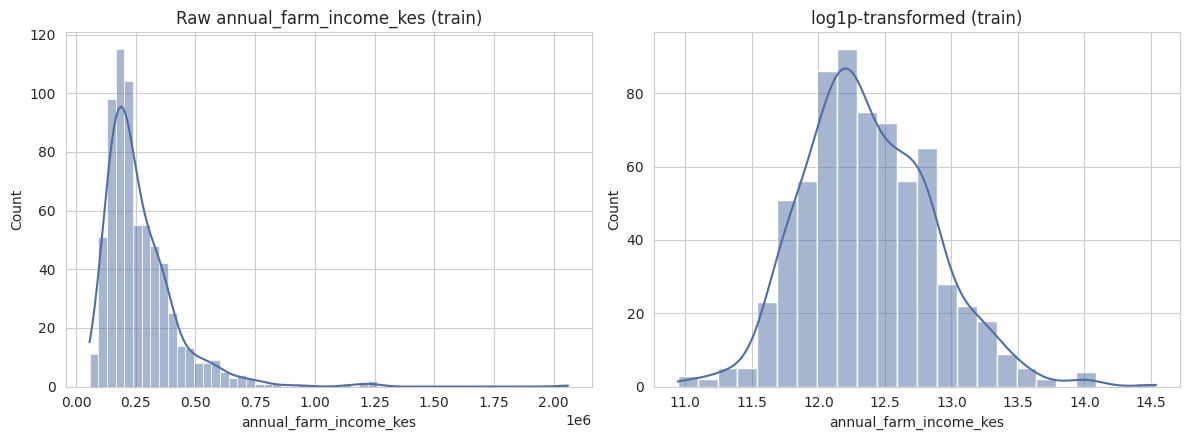

In [34]:
from scipy import stats

print(f"Raw y_train — skewness: {stats.skew(y_train):.2f}, kurtosis: {stats.kurtosis(y_train):.2f}")

y_train_log = np.log1p(y_train)
print(f"log1p(y_train) — skewness: {stats.skew(y_train_log):.2f}, kurtosis: {stats.kurtosis(y_train_log):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(y_train, kde=True, ax=axes[0], color='#4F6EA4')
axes[0].set_title('Raw annual_farm_income_kes (train)')
sns.histplot(y_train_log, kde=True, ax=axes[1], color='#4F6EA4')
axes[1].set_title('log1p-transformed (train)')
plt.tight_layout()
plt.show()

Raw target skewness is 3.62. log1p reduces this to 0.45 which is close to the 0 of a normal distribution and safely handles zero values if they appear in future data.

## 6. Modeling & Cross-Validation

### 6.1 Candidate Models

In [35]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

RANDOM_STATE = 42

# 5 fold split
cv_scheme = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidate_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=RANDOM_STATE, max_iter=10000),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}


In [36]:
print(f"""
5 candidate models were chosen.

The first group: Linear Regression, Ridge, and Lasso assumes income changes in a steady way as features change.
Section 2.4 showed that years_farming_experience is the only feature with a straight line relationship to income (Pearson = 0.528).
Every other numeric feature was close to zero.

The second group: Random Forest and Gradient Boosting does not assume a straight line relationship.
These models can pick up on more patterns that Pearson and Spearman correlation, done in Section 2.4, could not catch.

Ridge and Lasso have one more purpose: Section 4.2 found that farm_size_acres and num_workers_employed are correlated (r = 0.747).
Both features had VIF scores of 2.27 and 2.28 hence were not removed.
Ridge and Lasso check this overlap, since it works well with correlated features.""")


5 candidate models were chosen.

The first group: Linear Regression, Ridge, and Lasso assumes income changes in a steady way as features change.
Section 2.4 showed that years_farming_experience is the only feature with a straight line relationship to income (Pearson = 0.528).
Every other numeric feature was close to zero.

The second group: Random Forest and Gradient Boosting does not assume a straight line relationship.
These models can pick up on more patterns that Pearson and Spearman correlation, done in Section 2.4, could not catch.

Ridge and Lasso have one more purpose: Section 4.2 found that farm_size_acres and num_workers_employed are correlated (r = 0.747).
Both features had VIF scores of 2.27 and 2.28 hence were not removed.
Ridge and Lasso check this overlap, since it works well with correlated features.


### 6.2 K-Fold Cross-Validation Results

In [37]:
scoring = {
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error',
    'R2': 'r2',
}

results = []

# Goes through the 5 models, one at a time
for name, model in candidate_models.items():

    # Wrap each model so it trains on log1p(income) as done in section 5.3 but scores come back in KES
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', TransformedTargetRegressor(regressor=model, func=np.log1p, inverse_func=np.expm1))
    ])
    scores = cross_validate(pipe, X_train_corr, y_train, cv=cv_scheme, scoring=scoring, n_jobs=-1)
    results.append({
        'Model': name,
        'RMSE_mean': -scores['test_RMSE'].mean(),
        'RMSE_std': scores['test_RMSE'].std(),
        'MAE_mean': -scores['test_MAE'].mean(),
        'R2_mean': scores['test_R2'].mean(),
        'R2_std': scores['test_R2'].std(),
    })

# Display the results in a table
results_df = pd.DataFrame(results).sort_values('RMSE_mean')
results_df.round(2)

,Model,RMSE_mean,RMSE_std,MAE_mean,R2_mean,R2_std
0,Linear Regression,115518.46,44289.17,66257.14,0.49,0.16
1,Ridge Regression,115555.77,44296.80,66225.57,0.49,0.16
3,Random Forest,128165.84,41234.25,75876.57,0.37,0.14
4,Gradient Boosting,128564.08,38397.13,75085.16,0.36,0.11
2,Lasso Regression,164293.42,40479.09,104535.05,-0.05,0.04


In [38]:
print(f"""
The table above shows how well each of the 5 models predicted farm income, tested using 5-fold cross-validation.

Linear Regression and Ridge Regression have the lowest RMSE results and are not too far off from each other.
On average, their predictions were off by about KES 115,500, and they explained about 49% of the differences in income between
farms (R2 = 0.49).

Random Forest and Gradient Boosting did worse than Linear Regression and Ridge, since they have higher RMSE scores.
Their predictions were off by about KES 128,100 - 128,500, and they explained only 36 - 37% of the income differences.

Lasso Regression performed the worst. It has the highest RMSE score of all the models and its R2 score was negative (-0.05),
meaning it did worse than guessing the average income for every farm.

Linear Regression and Ridge scored almost the same, whereby they have a 37 KES gap, but Ridge is the only one of the two, that can be meaningfully tuned.
The chosen model is Ridge Regression to be used in Section 9 for hyperparameter tuning. """)


The table above shows how well each of the 5 models predicted farm income, tested using 5-fold cross-validation.

Linear Regression and Ridge Regression have the lowest RMSE results and are not too far off from each other.
On average, their predictions were off by about KES 115,500, and they explained about 49% of the differences in income between
farms (R2 = 0.49).

Random Forest and Gradient Boosting did worse than Linear Regression and Ridge, since they have higher RMSE scores.
Their predictions were off by about KES 128,100 - 128,500, and they explained only 36 - 37% of the income differences.

Lasso Regression performed the worst. It has the highest RMSE score of all the models and its R2 score was negative (-0.05),
meaning it did worse than guessing the average income for every farm.

Linear Regression and Ridge scored almost the same, whereby they have a 37 KES gap, but Ridge is the only one of the two, that can be meaningfully tuned.
The chosen model is Ridge Regression to be 

## 7. Diagnostics

### 7.1 Linearity

In [39]:
linear_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor),("model", LinearRegression())]
)

linear_pipeline.fit(X_train_corr, y_train_log)
fitted_values = linear_pipeline.predict(X_train_corr)
residuals = y_train_log.values - fitted_values

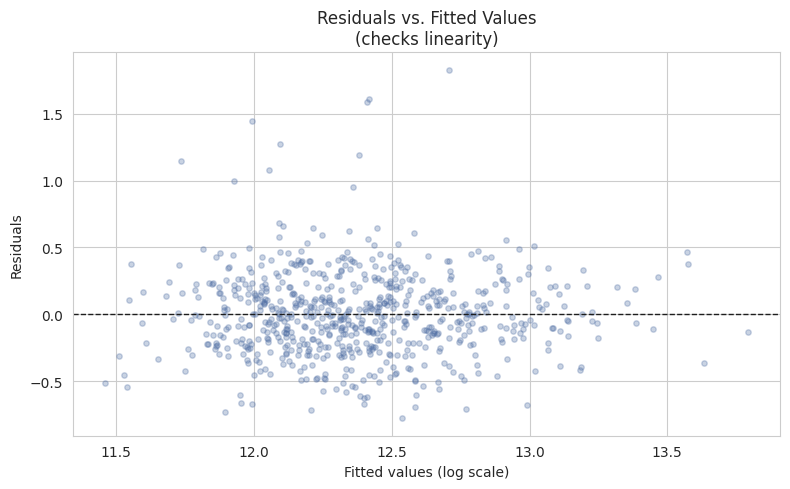

In [40]:
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

axes.scatter(fitted_values, residuals, alpha=0.3, s=15, color="#4F6EA4")
axes.axhline(0, color="#1D1D1D", linestyle="--", linewidth=1)
axes.set_xlabel("Fitted values (log scale)")
axes.set_ylabel("Residuals")
axes.set_title("Residuals vs. Fitted Values\n(checks linearity)")

plt.tight_layout()
plt.show()

Though there are some outliers, the graph shows that there is a linear relationship between the dependent and the independent variable is linear. As such a linear model would be appropriate to describe the relationship between the predictors and the dependent variable.

### 7.2 Autocorrelation

In [41]:
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.4f}")

Durbin-Watson statistic: 1.9481


The statistic of 1.9481 is very close to the reference value of 2 thus there is little to no proof of autocorrelation in the residuals. As such, it is safe to say that the errors are independent of each other.

### 7.3 Normality of Errors

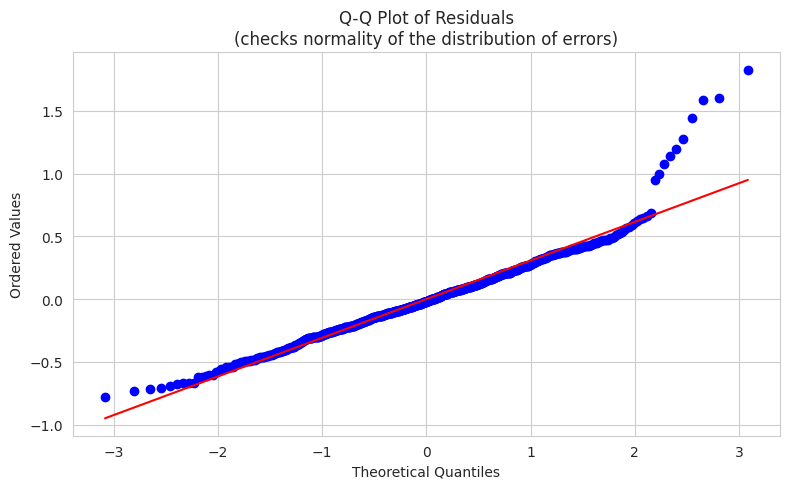

In [42]:
fig, axes = plt.subplots(1, 1, figsize=(8, 5))

stats.probplot(residuals, dist="norm", plot=axes)

axes.set_xlabel("Theoretical Quantiles")
axes.set_ylabel("Ordered Values")
axes.set_title("Q-Q Plot of Residuals\n(checks normality of the distribution of errors)")

plt.tight_layout()
plt.show()

Though most points follow the theoretical normal line especially in the central region, deviations start to occur at the lower tail and even more in the upper tail. Therefore, the normality assumption is not fully satisfied

### 7.4 Homoscedasticity

In [43]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

X_train_transformed = preprocessor.transform(X_train_corr)
# `sm.add_constant` adds one column of 1s so that the BP test's regression has
# an intercept. It is required by `het_breuschpagan()`
X_train_with_const = sm.add_constant(X_train_transformed)

bp_test = het_breuschpagan(residuals, X_train_with_const)
bp_labels = ["Breusch-Pagan LM (Lagrange Multiplier) Statistic", "Breusch-Pagan LM p-value", "F-Statistic", "F p-value"]
for label, value in zip(bp_labels, bp_test):
    print(f"{label}: {value:.4f}")

Breusch-Pagan LM (Lagrange Multiplier) Statistic: 19.2869
Breusch-Pagan LM p-value: 0.7365
F-Statistic: 0.9618
F p-value: 0.5076


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:1217: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y, x).fit()


The Breusch-Pagan test shows an LM p-value of 0.7365 and an F-test p-value of 0.5076 both of which are greater then the 0.05 significance level. Thus, it is safe to say that the homoscedasticity assumption is reasonably satisfied.

## 8. Evaluation of Candidate Models

### 8.1 Test-Set Performance Comparison

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

evaluation_results = []

for name, model in candidate_models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_train_corr, y_train_log)

    y_pred_log = pipeline.predict(X_test_corr)
    y_pred = np.expm1(y_pred_log)
    y_true = y_test.values

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2(r2, len(y_true), X_train_corr.shape[1])
    mape = mean_absolute_percentage_error(y_true, y_pred)

    evaluation_results.append({
        "Model": name, "MAE (KES)": mae, "MSE": mse, "RMSE (KES)": rmse,
        "R2": r2, "Adjusted R2": adj_r2, "MAPE (%)": mape
    })

evaluation_df = pd.DataFrame(evaluation_results).sort_values("RMSE (KES)")
evaluation_df.style.format({
    "MAE (KES)": "{:,.2f}", "MSE": "{:,.2f}", "RMSE (KES)": "{:,.2f}",
    "R2": "{:.3f}", "Adjusted R2": "{:.3f}", "MAPE (%)": "{:.2f}"
})

,Model,MAE (KES),MSE,RMSE (KES),R2,Adjusted R2,MAPE (%)
0,Linear Regression,"67,218.05","8,399,184,814.13","91,647.07",0.566,0.536,26.42
1,Ridge Regression,"67,212.20","8,406,318,566.11","91,685.98",0.566,0.536,26.41
4,Gradient Boosting,"69,464.82","9,231,827,214.68","96,082.40",0.523,0.490,27.29
3,Random Forest,"76,357.68","10,646,954,148.67","103,184.08",0.450,0.412,30.03
2,Lasso Regression,"100,379.02","20,246,961,087.45","142,291.82",-0.045,-0.118,40.20


From the results, it can be noted that Ridge Regression gave the least MAE of KES 67,212.20 and the least RMSE of KES 91,685.98, whereas Linear Regression followed closely with an MAE of KES 67,218.05 and RMSE of KES 91,647.07. Though Linear Regression had a slightly better RMSE compared to Ridge Regression, Ridge Regression gave the lesser MAE. In addition, both methods gave the same R² and Adjusted R² at 0.566 and 0.536 respectively; hence, they explained about 56.6% of the variations in the dependent variable.

The Gradient Boosting method performed reasonably well with an RMSE of KES 96,082.40 and R² of 0.523, while Random Forest gave the worst performance with an RMSE of KES 103,184.08 and R² of 0.450. Lasso Regression had the worst performance with RMSE of KES 142,291.82, R² of -0.045 and Adjusted R² of -0.118, indicating that the model performed worse than the mean prediction model on the test set. Thus, the results indicate that the regularised linear model and the linear model gave the best predictive performance amongst the candidate models.

### 8.2 Final Model Selection & Justification

The model chosen as the final model is the Ridge Regression model due to its having the minimum MAE of KES 67,212.20 and MAPE of 26.41% while maintaining an R² value of 0.566 and an Adjusted R² of 0.536. This means that the Ridge Regression Model gives good predictive performance as it maintains a good balance between prediction accuracy and model complexity.

Additionally, the Ridge Regression Model also gave slightly better MAE and MAPE, thus giving it better performance than the other models. It is also worth noting that Ridge Regression gives a model which performs regularisation and is therefore good when there is correlation among the predictors.The model shows reasonable generalisability and therefore can be used to predict the target variable.


## 9. Hyperparameter Tuning

### 9.1 Grid/Randomized Search

In [45]:
from sklearn.model_selection import GridSearchCV

# Tuning Ridge Regression model
untuned_ridge = Pipeline([
    ('preprocess', preprocessor),
    ('model', TransformedTargetRegressor(
        regressor=Ridge(random_state=RANDOM_STATE),
        # Train on log1p(income)
        func=np.log1p,
        # Convert back to KES
        inverse_func=np.expm1
    ))
])

# Test with several alpha values
param_grid = {
    'model__regressor__alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 200.0]
}

# GridSearchCV tries every alpha value above and for each one, it runs the same 5 fold cross validation used in Section 6.2
grid_search = GridSearchCV(
    untuned_ridge,
    param_grid,
    cv=cv_scheme,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True

)

# Keeps track of which alpha scored best
grid_search.fit(X_train_corr, y_train)

# Print out best alpha value
print("Best alpha value found:", grid_search.best_params_)


Best alpha value found: {'model__regressor__alpha': 0.01}


In [46]:
print(f"""
Ridge Regression model was chosen for tuning in section 6.2 since it has an alpha setting that can be tuned meaningfully.
The grid search tested the following eight alpha values: 0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 200, using the same 5 fold CV
scheme as Section 6.2.
The best alpha value found was 0.01.
""")


Ridge Regression model was chosen for tuning in section 6.2 since it has an alpha setting that can be tuned meaningfully.
The grid search tested the following eight alpha values: 0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0, 200, using the same 5 fold CV
scheme as Section 6.2.
The best alpha value found was 0.01.



### 9.2 Tuned vs. Untuned Comparison


In [47]:
# Test the untuned ridge using 5 fold CV and get its RMSE,MAE and R2
untuned_scores = cross_validate(
    untuned_ridge, X_train_corr, y_train,
    cv=cv_scheme, scoring=scoring, n_jobs=-1
)

# Test the tuned ridge using 5 fold CV and get its RMSE,MAE and R2
tuned_scores = cross_validate(
    grid_search.best_estimator_, X_train_corr, y_train,
    cv=cv_scheme, scoring=scoring, n_jobs=-1
)

# Table with one column for untuned and the other for tuned
comparison = pd.DataFrame({
    'Untuned (alpha=1.0 default)': {
        'RMSE': -untuned_scores['test_RMSE'].mean(),
        'MAE': -untuned_scores['test_MAE'].mean(),
        'R2': untuned_scores['test_R2'].mean(),
    },
    f"Tuned (alpha={grid_search.best_params_['model__regressor__alpha']})": {
        'RMSE': -tuned_scores['test_RMSE'].mean(),
        'MAE': -tuned_scores['test_MAE'].mean(),
        'R2': tuned_scores['test_R2'].mean(),
    }
}).round(2)
comparison

,Untuned (alpha=1.0 default),Tuned (alpha=0.01)
RMSE,115555.77,115518.80
MAE,66225.57,66256.82
R2,0.49,0.49


In [48]:
print(f"""
Tuning produced almost no improvement. RMSE moved from KES 115,555 to KES 115,518, a change of 37 KES.
MAE got a bit worse by moving from 66,225 to 66,256 and R² remained the same at 0.49.
This happened because the best alpha value found, 0.01, is close to zero meaning it made Ridge behave almost exactly like Linear Regression
rather than meaningfully shrinking its coefficients which would make us actually notice the difference in the numbers. """)


Tuning produced almost no improvement. RMSE moved from KES 115,555 to KES 115,518, a change of 37 KES.
MAE got a bit worse by moving from 66,225 to 66,256 and R² remained the same at 0.49.
This happened because the best alpha value found, 0.01, is close to zero meaning it made Ridge behave almost exactly like Linear Regression
rather than meaningfully shrinking its coefficients which would make us actually notice the difference in the numbers. 


## 10. Explainability

In [49]:
#10.1  Feature Importance / Coefficients
# Extract the final tuned pipeline selected by GridSearchCV
final_pipeline = grid_search.best_estimator_

# Extract the preprocessing component
final_preprocessor = final_pipeline.named_steps['preprocess']

# Extract the TransformedTargetRegressor
target_model = final_pipeline.named_steps['model']

# Extract the fitted Ridge regression model
ridge_model = target_model.regressor_

print("Final model:", ridge_model)
print("Best alpha:", ridge_model.alpha)

Final model: Ridge(alpha=0.01, random_state=42)
Best alpha: 0.01


In [50]:
# Get the feature names after preprocessing
feature_names = final_preprocessor.get_feature_names_out()

print(f"Number of transformed features: {len(feature_names)}")
print("\nTransformed features:")
for feature in feature_names:
    print(feature)

Number of transformed features: 24

Transformed features:
num_random__farm_size_acres
num_random__years_farming_experience
num_random__num_workers_employed
num_random__rainfall_mm
num_random__soil_quality_score
num_random__market_distance_km
num_structural__irrigation_maintenance_cost_kes
cat__crop_type_Coffee
cat__crop_type_Dairy
cat__crop_type_Horticulture
cat__crop_type_Maize
cat__crop_type_Tea
cat__county_Kericho
cat__county_Kiambu
cat__county_Meru
cat__county_Nakuru
cat__county_Other
cat__county_Uasin Gishu
cat__irrigation_type_Automated
cat__irrigation_type_Drip
cat__irrigation_type_Manual
cat__irrigation_type_None
cat__cooperative_member_No
cat__cooperative_member_Yes


In [51]:
# Extract Ridge coefficients
coefficients = ridge_model.coef_

coefficient_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
})

# Sort by absolute coefficient so the strongest relationships appear first
coefficient_df = coefficient_df.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

coefficient_df.head(15)

,Feature,Coefficient,Absolute_Coefficient
1,num_random__years_farming_experience,0.267181,0.267181
18,cat__irrigation_type_Automated,0.251772,0.251772
21,cat__irrigation_type_None,-0.236147,0.236147
16,cat__county_Other,-0.175774,0.175774
10,cat__crop_type_Maize,-0.162947,0.162947
9,cat__crop_type_Horticulture,0.152972,0.152972
12,cat__county_Kericho,0.085537,0.085537
20,cat__irrigation_type_Manual,-0.082321,0.082321
19,cat__irrigation_type_Drip,0.066695,0.066695
4,num_random__soil_quality_score,0.066431,0.066431


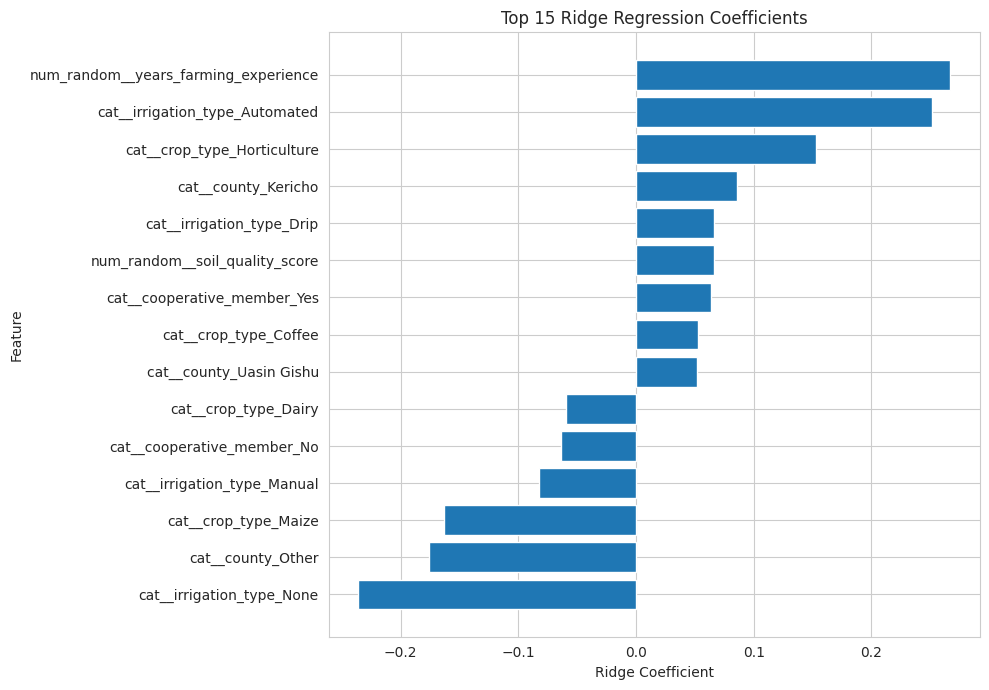

In [52]:
# Display the 15 strongest coefficients
top_coefficients = coefficient_df.head(15).sort_values('Coefficient')

plt.figure(figsize=(10, 7))

plt.barh(
    top_coefficients['Feature'],
    top_coefficients['Coefficient']
)

plt.xlabel('Ridge Coefficient')
plt.ylabel('Feature')
plt.title('Top 15 Ridge Regression Coefficients')

plt.tight_layout()
plt.show()

### 10.2 SHAP Analysis

In [53]:
%pip install shap

In [54]:
import shap

In [55]:
# Transform the training data using the fitted preprocessing pipeline
X_train_transformed = final_preprocessor.transform(X_train_corr)

# Convert sparse matrix to dense if necessary
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

print("Transformed training data shape:", X_train_transformed.shape)

Transformed training data shape: (680, 24)


In [56]:
# Create a SHAP LinearExplainer for the fitted Ridge model
explainer = shap.LinearExplainer(
    ridge_model,
    X_train_transformed
)

shap_values = explainer(X_train_transformed)

print("SHAP analysis completed.")

SHAP analysis completed.


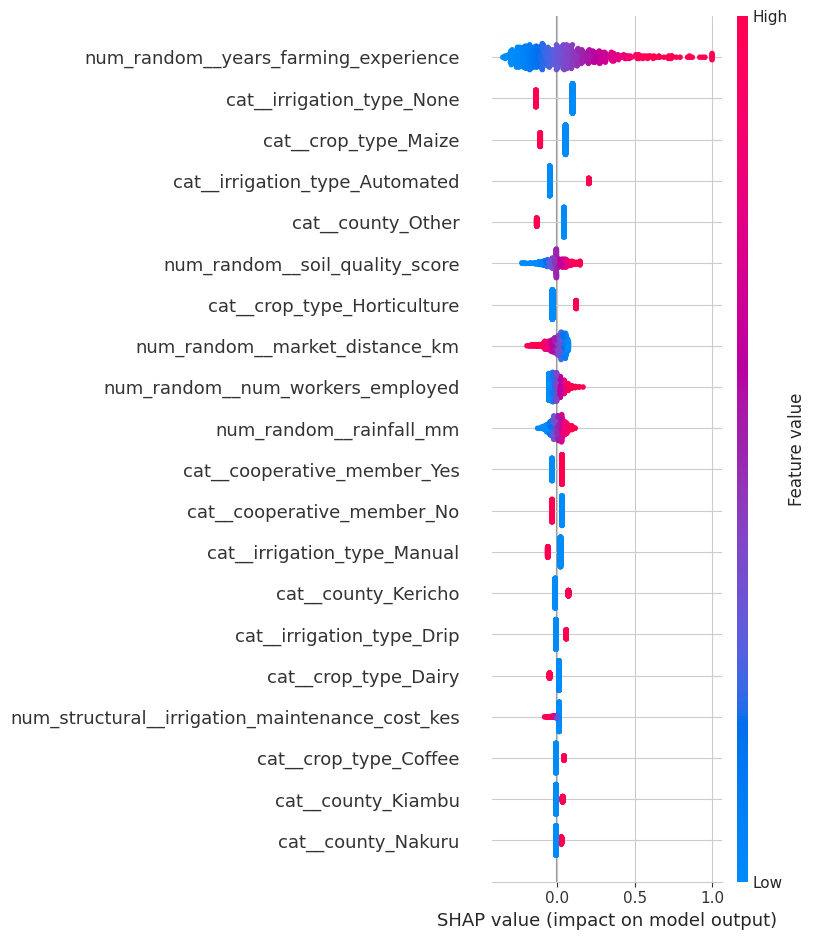

In [57]:
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    show=True
)

## 11. Model Persistence

### 11.1 Saving the Pipeline

In [58]:
# 11.1 Model Persistence - Saving the Pipeline

import joblib

# Get the final tuned pipeline selected by GridSearchCV
final_pipeline = grid_search.best_estimator_

# File name for the saved model
model_path = "farm_income_ridge_pipeline.joblib"

# Save the complete pipeline
joblib.dump(final_pipeline, model_path)

print(f"Pipeline saved successfully to: {model_path}")

Pipeline saved successfully to: farm_income_ridge_pipeline.joblib


### 11.2 Reload & Manual Prediction Demo

In [59]:
# 11.2 Reload the saved pipeline

# Load the saved pipeline
loaded_pipeline = joblib.load(model_path)

print("Pipeline loaded successfully.")
print(loaded_pipeline)

Pipeline loaded successfully.
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num_random',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['farm_size_acres',
                                                   'years_farming_experience',
                                                   'num_workers_employed',
                                                   'rainfall_mm',
                                                   'soil_quality_score',
                                                   'market_distance_km']),
                                                 ('num_structural',
                          

In [60]:
# Create a new farm for prediction

new_farm = pd.DataFrame({
    'farm_size_acres': [8.0],
    'years_farming_experience': [12],
    'num_workers_employed': [4],
    'rainfall_mm': [650],
    'soil_quality_score': [7.0],
    'market_distance_km': [15.0],
    'irrigation_maintenance_cost_kes': [0.0],
    'crop_type': ['Maize'],
    'county': ['Nakuru'],
    'irrigation_type': ['None'],
    'cooperative_member': ['Yes']
})

new_farm

,farm_size_acres,years_farming_experience,num_workers_employed,rainfall_mm,soil_quality_score,market_distance_km,irrigation_maintenance_cost_kes,crop_type,county,irrigation_type,cooperative_member
0,8.0,12,4,650,7.0,15.0,0.0,Maize,Nakuru,None,Yes


In [61]:
# Predict annual farm income for the new farm

predicted_income = loaded_pipeline.predict(new_farm)[0]

print(f"Predicted annual farm income: KES {predicted_income:,.2f}")

Predicted annual farm income: KES 147,010.48


In [62]:
print("Crop types:", farm_data['crop_type'].unique())
print("Counties:", farm_data['county'].unique())
print("Irrigation types:", farm_data['irrigation_type'].unique())
print("Cooperative membership:", farm_data['cooperative_member'].unique())

Crop types: ['Tea' 'Coffee' 'Maize' 'Dairy' 'Horticulture']
Counties: ['Uasin Gishu' 'Nakuru' 'Kericho' 'Meru' 'Kiambu' 'Other']
Irrigation types: ['Drip' 'None' 'Manual' 'Automated']
Cooperative membership: ['No' 'Yes']


## 12. Conclusion & Limitations